In [12]:
# Install libraries
!pip -q install mp-api pandas numpy matminer pymatgen

import pandas as pd
import numpy as np
from getpass import getpass
from mp_api.client import MPRester
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty
from google.colab import files

# Enter your Materials Project API key
API_KEY = getpass("Qeq9XgBt2ojVLS5Mpkd67IrfDHqSKuKO ")

# Properties to collect
fields = [
    "material_id",
    "formula_pretty",
    "band_gap",
    "is_gap_direct",
    "is_metal",
    "formation_energy_per_atom",
    "energy_above_hull",
    "density",
    "volume",
    "nsites",
    "nelements",
    "symmetry",
    "structure"
]

# Extract up to 10,000 materials
with MPRester(API_KEY) as mpr:

    # Check available fields
    available_fields = set(mpr.materials.summary.available_fields)
    fields = [field for field in fields if field in available_fields]

    docs = mpr.materials.summary.search(
        band_gap=(0.01, 10.0),
        deprecated=False,
        fields=fields,
        num_chunks=20,
        chunk_size=500
    )

# Convert to DataFrame
records = []

for doc in docs:
    symmetry = doc.symmetry

    records.append({
        "material_id": str(doc.material_id),
        "formula": doc.formula_pretty,
        "band_gap_eV": doc.band_gap,
        "is_gap_direct": doc.is_gap_direct,
        "is_metal": doc.is_metal,
        "formation_energy_eV_atom":
            doc.formation_energy_per_atom,
        "energy_above_hull_eV_atom":
            doc.energy_above_hull,
        "density_g_cm3": doc.density,
        "volume_A3": doc.volume,
        "number_of_sites": doc.nsites,
        "number_of_elements": doc.nelements,
        "crystal_system": (
            symmetry.crystal_system.value
            if symmetry else None
        ),
        "space_group": (
            symmetry.symbol if symmetry else None
        ),
        "structure": doc.structure
    })

df = pd.DataFrame(records)

# Clean data
df = df.drop_duplicates(subset="material_id")
df = df.dropna(subset=["band_gap_eV"])
df = df.reset_index(drop=True)

# Generate composition descriptors
featurizer = ElementProperty.from_preset("magpie")

composition_features = []

for formula in df["formula"]:
    try:
        comp = Composition(formula)
        values = featurizer.featurize(comp)
    except Exception:
        values = [np.nan] * len(featurizer.feature_labels())

    composition_features.append(values)

composition_df = pd.DataFrame(
    composition_features,
    columns=featurizer.feature_labels()
)

# Generate structural descriptors
structural_features = []

for structure in df["structure"]:
    if structure is not None:
        lattice = structure.lattice

        structural_features.append({
            "lattice_a": lattice.a,
            "lattice_b": lattice.b,
            "lattice_c": lattice.c,
            "alpha": lattice.alpha,
            "beta": lattice.beta,
            "gamma": lattice.gamma,
            "volume_per_atom": structure.volume / len(structure),
            "structure_density": structure.density,
            "structure_nsites": len(structure)
        })
    else:
        structural_features.append({
            "lattice_a": np.nan,
            "lattice_b": np.nan,
            "lattice_c": np.nan,
            "alpha": np.nan,
            "beta": np.nan,
            "gamma": np.nan,
            "volume_per_atom": np.nan,
            "structure_density": np.nan,
            "structure_nsites": np.nan
        })

structural_df = pd.DataFrame(structural_features)

# Combine all features
df = pd.concat(
    [
        df.drop(columns=["structure"]).reset_index(drop=True),
        composition_df.reset_index(drop=True),
        structural_df.reset_index(drop=True)
    ],
    axis=1
)

# Clean invalid values
df = df.replace([np.inf, -np.inf], np.nan)

# Save CSV
filename = "materials_bandgap_10k.csv"
df.to_csv(filename, index=False)

# Show results
print("Total materials collected:", len(df))
print("Total columns:", len(df.columns))
print("\nDataset preview:")
display(df.head())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

# Download CSV
files.download(filename)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 18.8 MB/s eta 0:00:00
Enter API key: ··········


Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Total materials collected: 10000
Total columns: 154

Dataset preview:


,material_id,formula,band_gap_eV,is_gap_direct,is_metal,formation_energy_eV_atom,energy_above_hull_eV_atom,density_g_cm3,volume_A3,number_of_sites,...,MagpieData mode SpaceGroupNumber,lattice_a,lattice_b,lattice_c,alpha,beta,gamma,volume_per_atom,structure_density,structure_nsites
0,mp-11107,Ac2O3,3.5219,False,False,-3.737668,0.000000,9.109130,91.511224,5,...,12.0,4.095487,4.095489,6.299882,90.000000,90.000000,120.000000,18.302245,9.109130,5
1,mp-32800,Ac2S3,2.2729,False,False,-2.493064,0.000000,6.535149,1118.407852,40,...,70.0,14.997851,14.997851,14.997851,144.742139,144.742139,50.718963,27.960196,6.535149,40
2,mp-977351,Ac2S3,3.0275,False,False,-2.440364,0.052700,5.562971,328.464893,10,...,70.0,7.619779,7.619773,7.875664,118.930903,61.069136,119.999942,32.846489,5.562971,10
3,mp-867311,AcAgTe2,0.0748,False,False,-0.996232,0.253251,7.997421,122.518406,4,...,152.0,5.574922,5.574922,5.574922,60.000000,60.000000,60.000000,30.629602,7.997421,4
4,mp-1183115,AcAlO3,4.1024,True,False,-3.690019,0.000000,8.728230,57.451413,5,...,12.0,3.858634,3.858634,3.858634,90.000000,90.000000,90.000000,11.490283,8.728230,5



Missing values:


,0
is_metal,8
material_id,0
formula,0
band_gap_eV,0
is_gap_direct,0
...,...
beta,0
gamma,0
volume_per_atom,0
structure_density,0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
df.isnull().sum()

,0
material_id,0
formula,0
band_gap_eV,0
is_gap_direct,0
is_metal,8
...,...
beta,0
gamma,0
volume_per_atom,0
structure_density,0


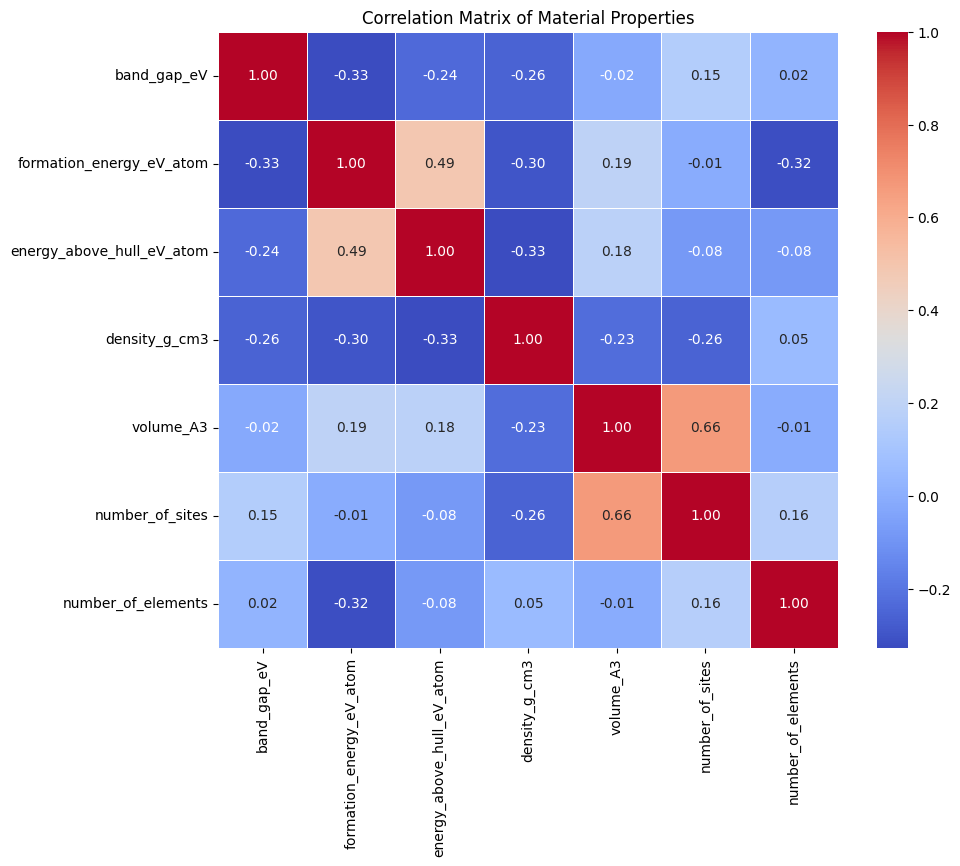

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation mapping
numerical_cols = [
    'band_gap_eV',
    'formation_energy_eV_atom',
    'energy_above_hull_eV_atom',
    'density_g_cm3',
    'volume_A3',
    'number_of_sites',
    'number_of_elements'
]

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Material Properties')
plt.show()

In [15]:
print("\nSummary statistics for numerical columns:")
display(df.describe())


Summary statistics for numerical columns:


,band_gap_eV,formation_energy_eV_atom,energy_above_hull_eV_atom,density_g_cm3,volume_A3,number_of_sites,number_of_elements,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,...,MagpieData mode SpaceGroupNumber,lattice_a,lattice_b,lattice_c,alpha,beta,gamma,volume_per_atom,structure_density,structure_nsites
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.255011,-1.993273,0.135807,4.412648,663.925360,38.731300,3.66770,9.136300,50.752800,41.616500,...,50.497500,7.740169,8.246676,10.980360,85.717475,87.757780,88.691857,22.323890,4.412648,38.731300
std,1.666932,1.156846,0.320100,1.840322,721.080274,35.021878,0.95654,7.994092,22.413767,21.745347,...,70.003372,3.210608,3.022657,5.402726,18.317465,16.777605,23.417916,48.807701,1.840322,35.021878
min,0.010100,-4.452467,0.000000,0.039581,11.286588,1.000000,1.00000,1.000000,4.000000,0.000000,...,2.000000,2.363000,2.363000,2.395898,7.345256,7.345259,7.345256,5.539658,0.039581,1.000000
25%,0.827225,-2.875682,0.001115,3.068729,255.898043,15.000000,3.00000,6.000000,32.000000,21.000000,...,12.000000,5.710632,6.040066,7.385846,76.937856,88.908527,85.852074,13.022679,3.068729,15.000000
50%,2.010900,-2.221849,0.032926,4.348892,488.573684,28.000000,4.00000,8.000000,56.000000,47.000000,...,12.000000,6.935430,7.685153,9.841033,90.000000,90.000000,90.000000,15.262681,4.348892,28.000000
75%,3.371075,-1.189965,0.135001,5.670049,827.636004,50.000000,4.00000,8.000000,65.000000,55.000000,...,64.000000,9.171929,9.842865,13.189662,90.000000,90.000000,93.302042,19.409571,5.670049,50.000000
max,9.065300,4.159950,5.074607,12.472296,19406.766762,344.000000,9.00000,83.000000,94.000000,92.000000,...,229.000000,37.266944,52.349372,94.039742,169.783994,169.783994,167.362623,1492.828212,12.472296,344.000000


In [16]:
df.duplicated()
df.isnull().sum()

,0
material_id,0
formula,0
band_gap_eV,0
is_gap_direct,0
is_metal,8
...,...
beta,0
gamma,0
volume_per_atom,0
structure_density,0


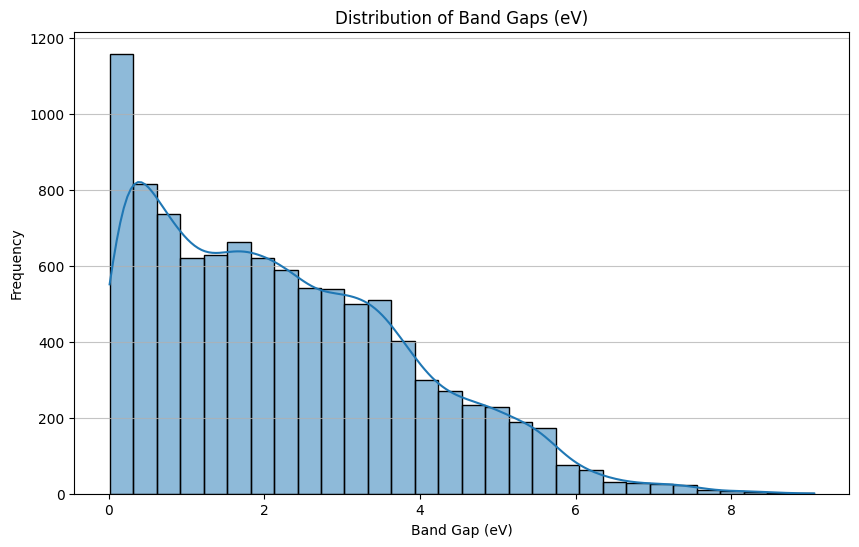

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['band_gap_eV'], bins=30, kde=True)
plt.title('Distribution of Band Gaps (eV)')
plt.xlabel('Band Gap (eV)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [18]:


!pip -q install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("/content/materials_bandgap_10k.csv")

# 2. Select independent variables and target

# Composition features
composition_features = [
    col for col in df.columns
    if col.startswith("MagpieData")
]

# Structural features
structural_features = [
    "lattice_a",
    "lattice_b",
    "lattice_c",
    "alpha",
    "beta",
    "gamma",
    "volume_per_atom",
    "structure_density",
    "structure_nsites"
]

# Keep only structural features present in dataset
structural_features = [
    col for col in structural_features
    if col in df.columns
]

# Combine composition and structural features
features = composition_features + structural_features

# Remove duplicate feature names
features = list(dict.fromkeys(features))

# Target variable
target = "band_gap_eV"

# Select X and y
X = df[features].copy()
y = df[target].copy()

# Convert features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows with missing target values
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)

print("Number of independent variables:", len(features))
print("Total samples:", len(X))

# 3. Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 4. Handle missing values
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

# 5. Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

# 6. Train model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

# 7. Make predictions
y_pred = rf_model.predict(X_test)

# 8. Evaluate model
print("\nRandom Forest Model Performance")
print("-------------------------------")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} eV")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} eV")

# 9. Actual vs predicted values
results = pd.DataFrame({
    "Actual Band Gap (eV)": y_test.values,
    "Predicted Band Gap (eV)": y_pred
})

print("\nActual vs Predicted Band Gaps:")
print(results.head(10))



Number of independent variables: 141
Total samples: 10000
Training samples: 8000
Testing samples: 2000
Random Forest training completed!

Random Forest Model Performance
-------------------------------
R² Score: 0.7299
MAE: 0.6069 eV
RMSE: 0.8583 eV

Actual vs Predicted Band Gaps:
   Actual Band Gap (eV)  Predicted Band Gap (eV)
0                0.0136                 0.310673
1                2.0817                 1.870165
2                3.1360                 2.126284
3                2.0466                 2.407039
4                1.2783                 0.977131
5                0.1058                 0.731537
6                5.0602                 4.879382
7                1.8436                 1.346882
8                3.5021                 3.454377
9                0.5517                 1.406179


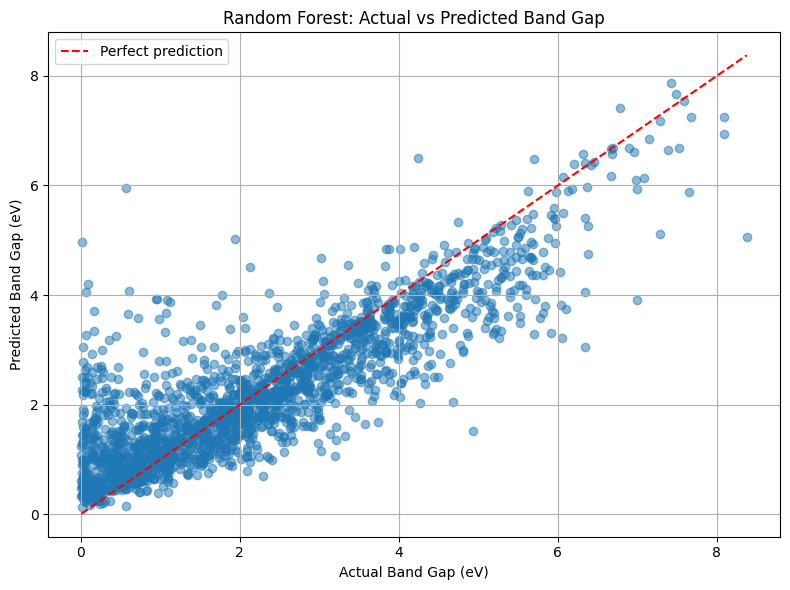

In [19]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot(
    [low, high], [low, high],
    "r--", label="Perfect prediction"
)

plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Random Forest: Actual vs Predicted Band Gap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
# XGBOOST MODEL FOR BAND GAP PREDICTION

!pip -q install xgboost scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("/content/materials_bandgap_10k.csv")

# 2. Select independent variables and target

# Composition features
composition_features = [
    col for col in df.columns
    if col.startswith("MagpieData")
]

# Structural features
structural_features = [
    "lattice_a",
    "lattice_b",
    "lattice_c",
    "alpha",
    "beta",
    "gamma",
    "volume_per_atom",
    "structure_density",
    "structure_nsites"
]

# Keep only structural features present in the dataset
structural_features = [
    col for col in structural_features
    if col in df.columns
]

# Combine composition and structural features
features = composition_features + structural_features

# Remove duplicate feature names
features = list(dict.fromkeys(features))

# Target variable
target = "band_gap_eV"

# Select X and y
X = df[features].copy()
y = df[target].copy()

# Convert features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows with missing target values
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)

print("Number of independent variables:", len(features))
print("Total samples:", len(X))

# 3. Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 4. Handle missing values
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

# 5. Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# 6. Train model
xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

# 7. Make predictions
y_pred = xgb_model.predict(X_test)

# 8. Evaluate model
print("\nXGBoost Model Performance")
print("-------------------------")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} eV")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} eV")

# 9. Actual vs predicted values
results = pd.DataFrame({
    "Actual Band Gap (eV)": y_test.values,
    "Predicted Band Gap (eV)": y_pred
})

print("\nActual vs Predicted Band Gaps:")
print(results.head(10))



Number of independent variables: 141
Total samples: 10000
Training samples: 8000
Testing samples: 2000
XGBoost training completed!

XGBoost Model Performance
-------------------------
R² Score: 0.7281
MAE: 0.6266 eV
RMSE: 0.8611 eV

Actual vs Predicted Band Gaps:
   Actual Band Gap (eV)  Predicted Band Gap (eV)
0                0.0136                 0.532494
1                2.0817                 1.873854
2                3.1360                 2.541067
3                2.0466                 2.529979
4                1.2783                 1.072485
5                0.1058                 0.806542
6                5.0602                 4.853259
7                1.8436                 1.248235
8                3.5021                 3.229392
9                0.5517                 1.263823


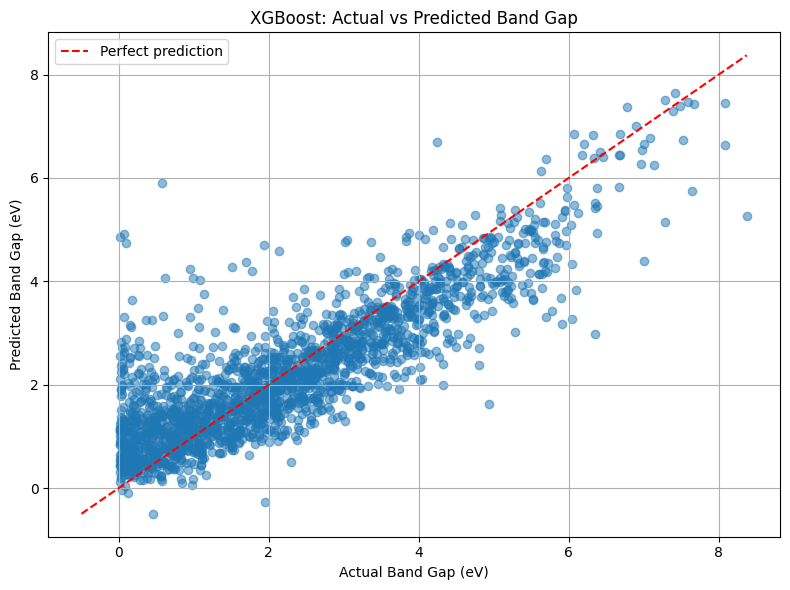

In [21]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot(
    [low, high], [low, high],
    "r--", label="Perfect prediction"
)

plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("XGBoost: Actual vs Predicted Band Gap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

